In [6]:
import pandas as pd
import numpy as np
import training_pipeline.train_maven_support as TS
import data_processing_pipeline.pipeline_support as PS
import pickle
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr
import seaborn as sns
from matplotlib.lines import Line2D
import gzip
import os
import shutil

import warnings      
warnings.filterwarnings("ignore")

In [8]:
os.getcwd()

'/Users/vivekkanpa/Documents/ISMMS/LAB_WORK/Kuan-lin_Huang_Lab/Reproducible_analysis_MAVEN'

#### Read in MAVEN scores and metadata 

In [10]:
maven_metadata = pd.read_csv('resource_data/MAVEDB_metadata.csv', index_col=0)
maven_metadata = maven_metadata[maven_metadata['Training']==0]
maven_metadata['UniProt_ID'] = [i + '_HUMAN' for i in maven_metadata['Approved Symbol']]

In [12]:
proteingym_metadata = pd.read_csv('resource_data/proteingym_data/DMS_substitutions.csv')
proteingym_metadata = proteingym_metadata[proteingym_metadata['taxon'] == 'Human']
proteingym_metadata['Protein'] = [protein_code.split('_')[0] for protein_code in proteingym_metadata['UniProt_ID']]

FileNotFoundError: [Errno 2] No such file or directory: 'resource_data/proteingym_data/DMS_substitutions.csv'

In [ ]:
proteingym_metadata

In [6]:
validation_proteins = proteingym_metadata['Protein'].values

# There should be 96 Human MAVE datasets in MAVEN metadata
len(validation_proteins)

96

In [7]:
y_percentile = 40
version = 'v1.0.0'

features = PS.file_to_list('maven_' + version + '/data' +  '/percentile_'+str(y_percentile)+ '/maven_all_features_order.txt')
training_genes  = PS.file_to_list('maven_'+version+'/data/percentile_'+str(y_percentile) +'/'+'ensembl_all_training_genes.txt')
cpt1_training_genes = ['SUMO1','UBE2I','TPK1','MTHFR','CALM1']
training_genes = training_genes + cpt1_training_genes
numeric_cols = PS.file_to_list('resource_data/s8-ml-training-data/numeric_features.txt')
label_col = 'MAVE_score_binary_' + str(y_percentile) +'_percentile'

In [8]:
id_mapper = pd.read_csv('resource_data/proteingym_data/human_prot_idmapping.tsv', sep='\t')
proteingym_metadata = pd.merge(proteingym_metadata,
                               id_mapper,
                               left_on='UniProt_ID',
                               right_on='Entry Name')

In [9]:
'''
file_list = []

for i in proteingym_metadata['UniProt_ID'].values:
    fn = id_mapper[id_mapper['From'] == i]['Entry'].values[0]
    file_list.append('{}_maven.tsv.gz'.format(fn))

# Source directory (where files currently are)
src_dir = "../MAVEN_proteingym/ProteinGym_Benchmark/maven_predictions/percentile_40"

# Destination directory (where you want to copy files to)
dst_dir = "resource_data/proteingym_data/MAVEN_predictions"

# Make sure the destination directory exists
os.makedirs(dst_dir, exist_ok=True)

# Copy each file
for file_name in file_list:
    src_path = os.path.join(src_dir, file_name)
    dst_path = os.path.join(dst_dir, os.path.basename(file_name))  # strips subfolders

    try:
        shutil.copy2(src_path, dst_path)  # copy2 preserves metadata
        #print(f"Copied: {src_path} → {dst_path}")
    except Exception as e:
        print(f"Failed to copy {src_path}: {e}")
'''

'\nfile_list = []\n\nfor i in proteingym_metadata[\'UniProt_ID\'].values:\n    fn = id_mapper[id_mapper[\'From\'] == i][\'Entry\'].values[0]\n    file_list.append(\'{}_maven.tsv.gz\'.format(fn))\n\n# Source directory (where files currently are)\nsrc_dir = "../MAVEN_proteingym/ProteinGym_Benchmark/maven_predictions/percentile_40"\n\n# Destination directory (where you want to copy files to)\ndst_dir = "resource_data/proteingym_data/MAVEN_predictions"\n\n# Make sure the destination directory exists\nos.makedirs(dst_dir, exist_ok=True)\n\n# Copy each file\nfor file_name in file_list:\n    src_path = os.path.join(src_dir, file_name)\n    dst_path = os.path.join(dst_dir, os.path.basename(file_name))  # strips subfolders\n\n    try:\n        shutil.copy2(src_path, dst_path)  # copy2 preserves metadata\n        #print(f"Copied: {src_path} → {dst_path}")\n    except Exception as e:\n        print(f"Failed to copy {src_path}: {e}")\n'

In [10]:
# for each proteingym human MAVE, do the following...
# (A) add MAVEN prediction dataframe for that protein to maven_predictions
# (B) concatenate the amino acid sequence from MAVEN prediction dataframe
# (C) extract the ProteinGym amino acid sequence from ProteinGym metadata

maven_predictions = dict()
maven_seq = dict()
PG_seq = dict()

for i in proteingym_metadata['UniProt_ID'].values:
    uniprot = id_mapper[id_mapper['From'] == i]['Entry'].values[0]
    full_path = 'resource_data/proteingym_data/MAVEN_predictions/{}_maven.tsv.gz'.format(uniprot)
    if os.path.exists(full_path):
        maven_predictions[i.split('_')[0]] = pd.read_csv(full_path, sep='\t',compression='gzip',index_col=0,low_memory=False)
    else:
        maven_predictions[i.split('_')[0]] = pd.DataFrame(columns=['aapos', 'aaref'])

    maven_seq[i.split('_')[0]] = ''.join(maven_predictions[i.split('_')[0]][['aapos', 'aaref']].drop_duplicates()['aaref'].values)
    PG_seq[i.split('_')[0]] = proteingym_metadata[proteingym_metadata['Protein'] == i.split('_')[0]].target_seq.values[0]

In [11]:
# dataframe of MAVEN and ProteinGym sequences for each MAVE
ref_seqs = pd.merge(pd.DataFrame(maven_seq, index=['MAVEN_seq']).T,
                     pd.DataFrame(maven_seq, index=['PG_seq']).T,
                     left_index=True, right_index=True)

#### Read in VEP score files

In [13]:
def list_csv_files(root_dir):
    csv_files = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    return csv_files

# List the csv files stored within ProteinGym MAVE/VEP file directory system
csv_paths = list_csv_files('resource_data/proteingym_data/zero_shot_substitutions_scores/')
print(len(csv_paths))

12373


In [14]:
# Only include genuine .csv files in the list (remove .ipynb_checkpoints)
fn_subset = []
vep_dict = dict()
for fn in csv_paths:
    if '.ipynb_checkpoints' not in '/'.join(fn.split('/')[1:-1]):
        vep_dict['/'.join(fn.split('/')[3:-1])] = []

In [15]:
# Create a dictionary with key value pairs stored as... (str) VEP name:(list) MAVE files
for vep in vep_dict:
        MAVE_list = list_csv_files('resource_data/proteingym_data/zero_shot_substitutions_scores/' + vep)
        human_MAVE_list = []
        for fn in MAVE_list:
            MAVE_file = fn.split('/')[-1]
            if 'HUMAN' in MAVE_file:
                human_MAVE_list.append(MAVE_file)

        vep_dict[vep] = human_MAVE_list

In [16]:
proteingym_metadata[proteingym_metadata['DMS_number_single_mutants'] == proteingym_metadata['DMS_number_single_mutants'].max()]

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,coarse_selection_type,Protein,From,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length
30,HMDH_HUMAN_Jiang_2019,HMDH_HUMAN_Jiang_2019.csv,HMDH_HUMAN,Human,Homo sapiens,MLSRLFRMHGLFVASHPWEVIVGTVTLTICMMSMNMFTGNNKICGW...,888,False,16853,16853,...,OrganismalFitness,HMDH,HMDH_HUMAN,P04035,reviewed,HMDH_HUMAN,3-hydroxy-3-methylglutaryl-coenzyme A reductas...,HMGCR,Homo sapiens (Human),888


In [17]:
paths_df = pd.DataFrame(vep_dict)
paths_df

,RITA/large,RITA/medium,RITA/small,RITA/xlarge,MULAN/MULAN_small,VespaG,ProtGPT2,Tranception/Tranception_L_reruns,Tranception/Tranception_M,Tranception/Tranception_L,...,Progen2/base,ProteinMPNN,Tranception_no_retrieval/Tranception_M,Tranception_no_retrieval/Tranception_L,Tranception_no_retrieval/Tranception_S,TranceptEVE/TranceptEVE_M,TranceptEVE/TranceptEVE_L,TranceptEVE/TranceptEVE_S,MIF/mifst,MIF/mif
0,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,...,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN_Huttinger_2021.csv
1,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,...,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN_Yee_2023_activity.csv
2,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,...,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv,ACE2_HUMAN_Chan_2020.csv
3,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,...,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv,CASP3_HUMAN_Roychowdhury_2020.csv
4,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,...,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,KCNH2_HUMAN_Kozek_2020.csv,KCNH2_HUMAN_Kozek_2020.c

#### Scoring against MAVEN

In [19]:
# Generates mutation annotation using reference sequence and mutation code
def get_mutation(ref, mut):
    mutations = []
    for i, (r, m) in enumerate(zip(ref, mut)):
        if r != m:
            mutations.append(f"{r}{i+1}{m}")
    return ';'.join(mutations) if mutations else 'WT'  # WT = wild-type (no mutation)

In [20]:
# Finds the index at which the MAVEN and ProteinGym metadata reference sequences have the greatest overlap.
# Return the "best_index" aka the index where there is the greatest alignment. This is the positional offset.
def find_max_overlap_index(maven_seq, ref_seq):
    max_overlap = 0
    best_index = -1

    for i in range(len(maven_seq)):
        # Get the substring from maven_seq starting at i with the length of ref_seq (or shorter if at end)
        overlap_len = min(len(ref_seq), len(maven_seq) - i)
        maven_sub = maven_seq[i:i + overlap_len]
        ref_sub = ref_seq[:overlap_len]

        matches = sum(1 for a, b in zip(maven_sub, ref_sub) if a == b)

        if matches > max_overlap:
            max_overlap = matches
            best_index = i

    return best_index, max_overlap

In [21]:
# Identify the VEP score column dynamically across all VEP dataframes
def get_float_column_name(df):
    float_columns = df.select_dtypes(include=['float', 'float64', 'float32']).columns
    if len(float_columns) == 0:
        raise ValueError("No float columns found.")
    elif len(float_columns) == 1:
        return float_columns[0], False
    else:
        if float_columns[-1] != 'DMS_score':
            print('\t!!! Multiple possible score columns{}; using {} by default'.format(float_columns, float_columns[-1]))
            return float_columns[-1], True
        else:
            print('\t!!! Multiple possible score columns{}; using {} by default'.format(float_columns, float_columns[-2]))
            return float_columns[-2], True

In [22]:
# For each VEP, iterate thru each MAVE. Read the MAVE scores file for that VEP, and merge the score column of 
# this dataframe with the MAVEN predictions dataframe based on variant position after offsetting (sequence alignment).
# Throw a warning in there is low sequence overlap (less than 90%) between ProteinGym and MAVEN-sourced transcripts. 
# Calculate the Spearman coefficient per MAVE dataset, and store alignment metadata in spearman_scoring.

spearman_scoring = []
spearman_dict = dict()

for VEP_name in paths_df.columns:

    VEP_scores = dict()
    
    lo_MAVEs = paths_df[VEP_name].values
    for MAVE_name in lo_MAVEs: #['AMFR_HUMAN_Tsuboyama_2023_4G3O.csv']:

        protein_name = MAVE_name.split('_')[0]
        if maven_predictions[protein_name].shape[0] > 0:
        
            path = VEP_name + '/' + MAVE_name

            ##### VEP score and ground truth merging
    
            VEP_preds = pd.read_csv('resource_data/proteingym_data/zero_shot_substitutions_scores/' + path)
            score_column, multiple_score_columns = get_float_column_name(VEP_preds)

            ground_truths = pd.read_csv('resource_data/proteingym_data/DMS_ProteinGym_substitutions/' + MAVE_name)
            ground_truths = ground_truths[['mutant', 'DMS_score']]

            ref_seq = proteingym_metadata[proteingym_metadata['DMS_filename'] == MAVE_name].target_seq.values[0]
            if 'mutant' not in VEP_preds.columns:
                VEP_preds['mutant'] = VEP_preds['mutated_sequence'].apply(lambda x: get_mutation(ref_seq, x))
            
            if 'DMS_score' not in VEP_preds.columns:
                VEP_preds = pd.merge(VEP_preds, ground_truths, left_on='mutant', right_on='mutant')

            ##### VEP score/GT dataframe formatting
            
            VEP_preds = VEP_preds[~VEP_preds['mutant'].str.contains(":", na=False)]
            VEP_preds = VEP_preds[~VEP_preds['mutant'].str.contains(";", na=False)]
            VEP_preds['aaref'] = [code[0:1] for code in VEP_preds['mutant']]
            VEP_preds['aapos'] = [code[1:-1] for code in VEP_preds['mutant']]
            VEP_preds['aaalt'] = [code[-1:] for code in VEP_preds['mutant']]

            ##### MAVEN score dataframe formatting
            
            MAVEN_preds = maven_predictions[protein_name]
            MAVEN_preds['mutant'] = MAVEN_preds['aaref'] + MAVEN_preds['aapos'].astype(str) + MAVEN_preds['aaalt']
            maven_seq = ''.join(MAVEN_preds[['aaref', 'aapos']].sort_values(by='aapos').drop_duplicates().aaref.values)

            ##### Transcript alignment
            
            offset_pos, overlap_size = find_max_overlap_index(maven_seq, ref_seq)
            adequate_overlap = True
            if overlap_size/len(ref_seq) < 0.9:
                print("!!! {} has an overlap proportion of {}. Check transcript.".format(protein_name, overlap_size))
                adequate_overlap = False
            
            VEP_preds['offset_pos'] = VEP_preds['aapos'].astype(int) + offset_pos
            VEP_preds['offset_mutant'] = VEP_preds['aaref'] + VEP_preds['offset_pos'].astype(str) + VEP_preds['aaalt']

            
            variant_aligned_df = pd.merge(MAVEN_preds[['mutant', 'MAVEN_score', 'MAVEN_(average)_score']], 
                                          VEP_preds[['offset_mutant', score_column, 'DMS_score']], left_on='mutant', right_on='offset_mutant')


            
            ##### Score calcuation
            maven_score = abs(spearmanr(variant_aligned_df['MAVEN_score'], variant_aligned_df['DMS_score'])[0])
            maven_avg_score =abs(spearmanr(variant_aligned_df['MAVEN_(average)_score'], variant_aligned_df['DMS_score'])[0])
            vep_score = abs(spearmanr(variant_aligned_df[score_column], variant_aligned_df['DMS_score'])[0])
            variant_count = variant_aligned_df.shape[0]
            available_protgym_variants = VEP_preds.shape[0]

            spearman_scoring.append([VEP_name, MAVE_name, vep_score, maven_score, maven_avg_score, multiple_score_columns, adequate_overlap, variant_count, available_protgym_variants])

            VEP_scores[MAVE_name] = vep_score  

    spearman_dict[VEP_name] = VEP_scores
    print("\033[1m{} complete\033[0m".format(VEP_name))

!!! RASK has an overlap proportion of 167. Check transcript.
!!! RASK has an overlap proportion of 167. Check transcript.
RITA/large complete
!!! RASK has an overlap proportion of 167. Check transcript.
!!! RASK has an overlap proportion of 167. Check transcript.
RITA/medium complete
!!! RASK has an overlap proportion of 167. Check transcript.
!!! RASK has an overlap proportion of 167. Check transcript.
RITA/small complete
!!! RASK has an overlap proportion of 167. Check transcript.
!!! RASK has an overlap proportion of 167. Check transcript.
RITA/xlarge complete
	!!! Multiple possible score columnsIndex(['MULAN_score', 'DMS_score'], dtype='object'); using MULAN_score by default
	!!! Multiple possible score columnsIndex(['MULAN_score', 'DMS_score'], dtype='object'); using MULAN_score by default
	!!! Multiple possible score columnsIndex(['MULAN_score', 'DMS_score'], dtype='object'); using MULAN_score by default
	!!! Multiple possible score columnsIndex(['MULAN_score', 'DMS_score'], dtyp

In [23]:
scoring_df = pd.DataFrame(spearman_scoring, columns=['VEP', 'MAVE', 'VEP_score', 'MAVEN_score', 'MAVEN_(average)_score', 
                                                    'multiple_score_columns', 'adequate_overlap', 'Variant_count', 'Available_PG_variants'])


In [24]:
scoring_df.head()

,VEP,MAVE,VEP_score,MAVEN_score,MAVEN_(average)_score,multiple_score_columns,adequate_overlap,Variant_count,Available_PG_variants
0,RITA/large,PAI1_HUMAN_Huttinger_2021.csv,0.364390,0.474736,0.499558,False,True,5345,5345
1,RITA/large,S22A1_HUMAN_Yee_2023_activity.csv,0.570310,0.596678,0.544035,False,True,10094,10094
2,RITA/large,ACE2_HUMAN_Chan_2020.csv,0.174910,0.348724,0.385999,False,True,2223,2223
3,RITA/large,CASP3_HUMAN_Roychowdhury_2020.csv,0.513902,0.573719,0.562079,False,True,1507,1567
4,RITA/large,SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM.csv,0.353920,0.395793,0.310450,False,True,3637,3637


In [25]:
spearman_df = pd.DataFrame(spearman_dict)

# Extract substring before the first underscore
scoring_df["Gene"] = scoring_df["MAVE"].str.extract(r'^([^_]+)')

# Add unique suffixes for duplicates
counter = {}
unique_names = []

for base in scoring_df["Gene"]:
    if base in counter:
        counter[base] += 1
        unique_names.append(f"{base}_{counter[base]}")
    else:
        counter[base] = 1
        unique_names.append(base)

scoring_df["Gene"] = unique_names


fn_to_gene_mapper = dict()
genes = [file.split('_')[0] for file in spearman_df.index]

s0 = proteingym_metadata[proteingym_metadata['DMS_filename'].isin(list(set(scoring_df['MAVE'])))][['Protein', 'DMS_filename', 'coarse_selection_type']]
s0['protein_label'] = s0['Protein'] + ' ' + s0['coarse_selection_type']

for file in scoring_df['MAVE']:
    fn_to_gene_mapper[file] = s0[s0['DMS_filename'] == file].protein_label.values[0]

In [26]:
spearman_df = pd.merge(scoring_df[['MAVE', 'MAVEN_score', 'MAVEN_(average)_score']].drop_duplicates().set_index('MAVE'),
                         spearman_df, left_index=True, right_index=True)
spearman_df = pd.merge(pd.DataFrame(fn_to_gene_mapper, index=['protein_name']).T, 
                       spearman_df, left_index=True, right_index=True).set_index('protein_name')
spearman_df.shape

(90, 59)

#### Analysis results

In [28]:
# What VEP has the highest mean rank across ProteinGym MAVE datasets?
ranking_df = spearman_df.rank(axis=1, ascending=False, method='min')
pd.DataFrame(ranking_df.mean(), columns=['mean_rank']).sort_values(by='mean_rank')

,mean_rank
MAVEN_score,14.400000
ProSST/ProSST-2048,14.588889
MAVEN_(average)_score,17.322222
PoET,17.466667
SaProt/SaProt_650M_AF2,17.511111
VespaG,17.677778
TranceptEVE/TranceptEVE_M,18.933333
TranceptEVE/TranceptEVE_L,19.044444
ESM2/650M,19.433333
ProtSSN,19.522222


In [29]:
# What VEP has the highest mean Spearman across all ProteinGym MAVE datasets?
pd.DataFrame(spearman_df.mean(), columns=['mean_spearman']).sort_values(by='mean_spearman', ascending=False)[0:10]

,mean_spearman
ProSST/ProSST-2048,0.520357
MAVEN_(average)_score,0.516634
MAVEN_score,0.513765
ProSST/ProSST-4096,0.495177
ProSST/ProSST-1024,0.482227
PoET,0.481892
SaProt/SaProt_650M_AF2,0.478651
ProtSSN,0.477878
VespaG,0.476438
TranceptEVE/TranceptEVE_M,0.469104


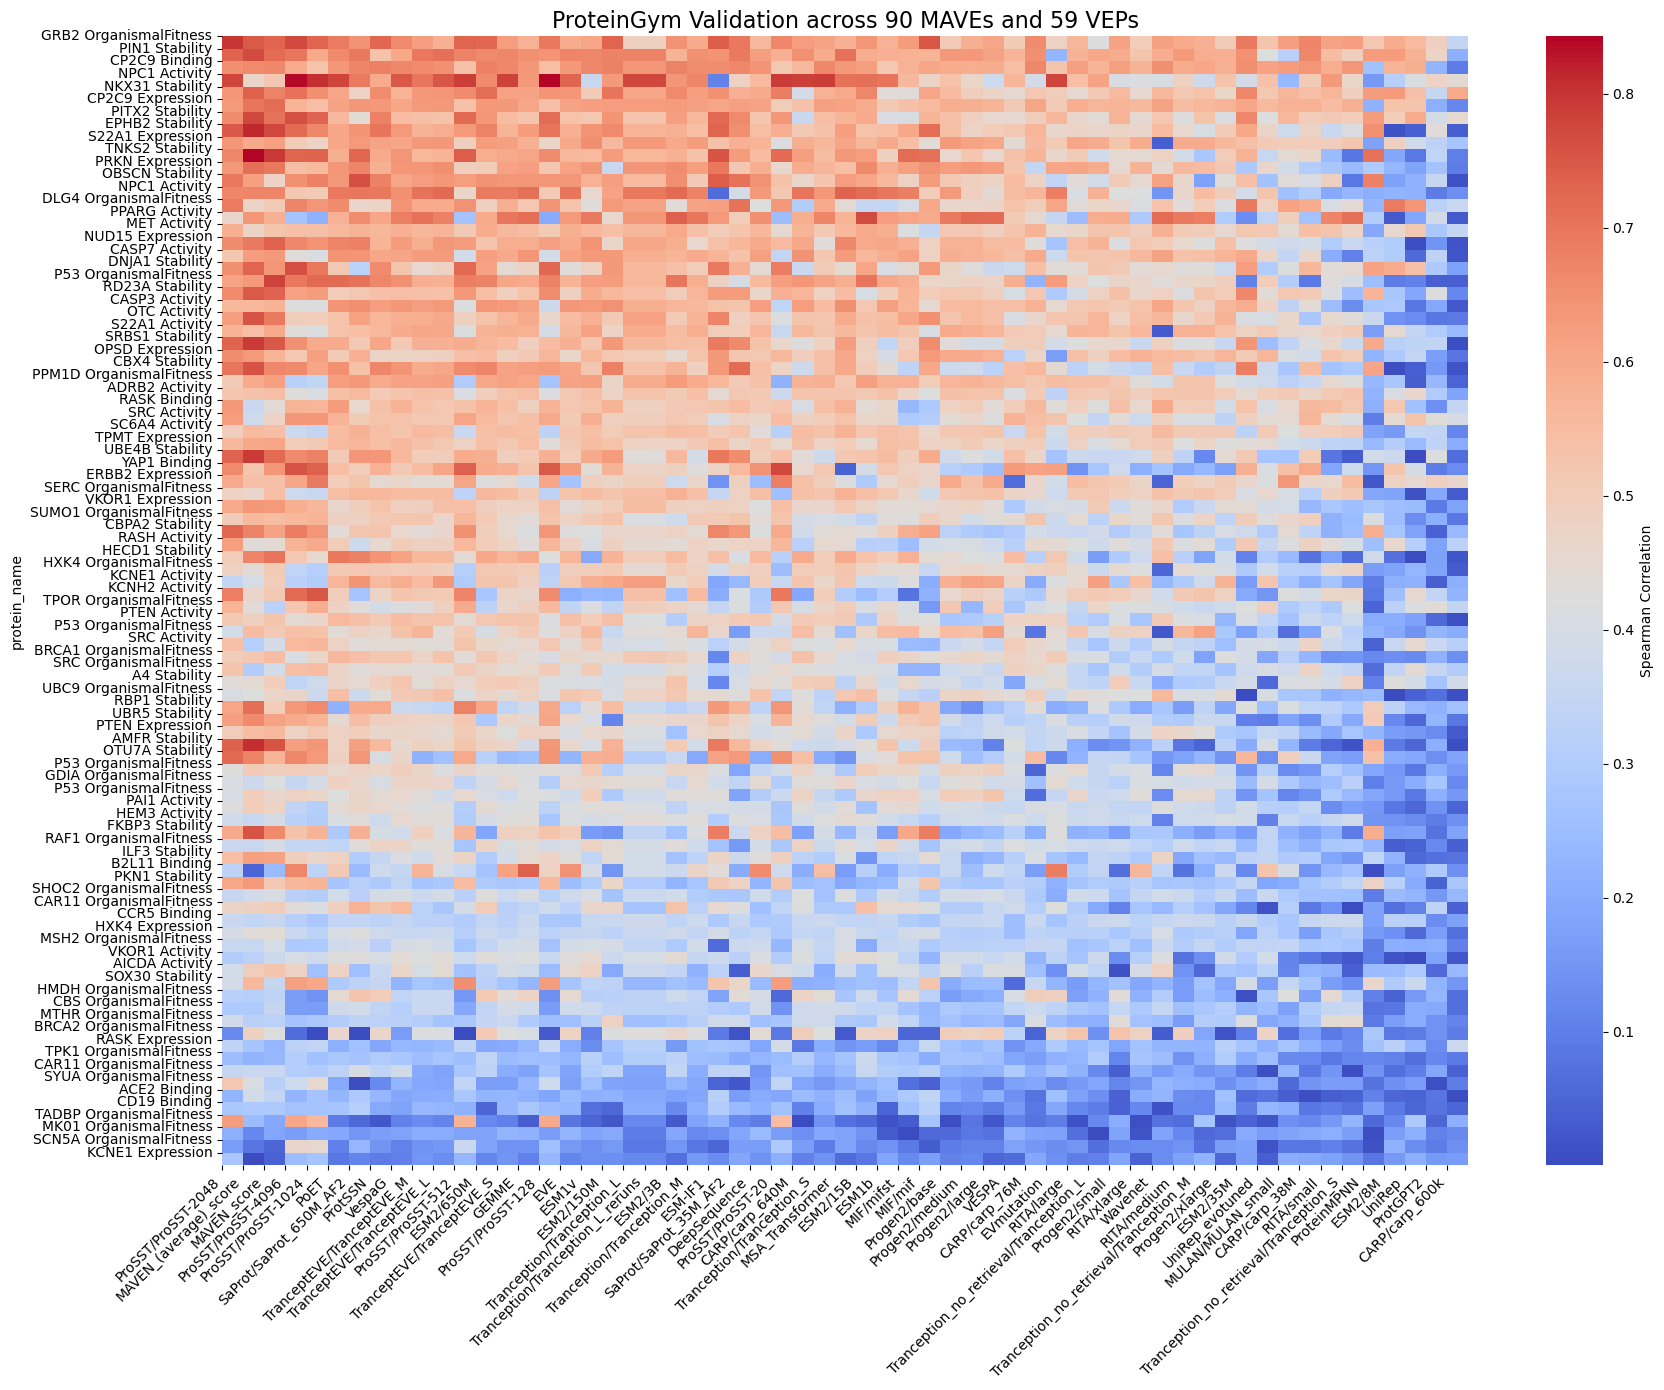

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list

# Step 1: Compute average performance
row_avg = spearman_df.mean(axis=1)  # average performance per MAVE
col_avg = spearman_df.mean(axis=0)  # average performance per VEP

# Step 2: Hierarchical clustering on rows and columns
row_linkage = linkage(spearman_df, method='average', metric='euclidean')
col_linkage = linkage(spearman_df.T, method='average', metric='euclidean')

# Step 3: Get leaves order from linkage matrices
row_leaves = leaves_list(row_linkage)
col_leaves = leaves_list(col_linkage)

# Step 4: Sort leaves by average performance (descending)
sorted_row_leaves = [i for i in row_leaves[np.argsort(-row_avg.iloc[row_leaves].values)]]
sorted_col_leaves = [i for i in col_leaves[np.argsort(-col_avg.iloc[col_leaves].values)]]

# Step 5: Reorder the dataframe
spearman_df_sorted = spearman_df.iloc[sorted_row_leaves, sorted_col_leaves]

# Step 6: Plot heatmap
plt.figure(figsize=(18, 14))
ax = sns.heatmap(spearman_df_sorted, cmap='coolwarm', annot=False,
                cbar_kws={"label": "Spearman Correlation"}
)

# Ticks
ax.set_xticks(range(spearman_df_sorted.shape[1]))
ax.set_xticklabels(spearman_df_sorted.columns, rotation=45, ha='right')

ax.set_yticks(range(spearman_df_sorted.shape[0]))
ax.set_yticklabels(spearman_df_sorted.index, rotation=0)

plt.title("ProteinGym Validation across 90 MAVEs and 59 VEPs", fontsize=16)
plt.tight_layout()
plt.show()


In [60]:
spearman_df

,MAVEN_score,MAVEN_(average)_score,RITA/large,RITA/medium,RITA/small,RITA/xlarge,MULAN/MULAN_small,VespaG,ProtGPT2,Tranception/Tranception_L_reruns,...,Progen2/base,ProteinMPNN,Tranception_no_retrieval/Tranception_M,Tranception_no_retrieval/Tranception_L,Tranception_no_retrieval/Tranception_S,TranceptEVE/TranceptEVE_M,TranceptEVE/TranceptEVE_L,TranceptEVE/TranceptEVE_S,MIF/mifst,MIF/mif
protein_name,,,,,,,,,,,,,,,,,,,,,
PAI1 Activity,0.474736,0.499558,0.364390,0.380991,0.131801,0.345432,0.310327,0.434962,0.140915,0.411526,...,0.398775,0.151865,0.370060,0.378812,0.170540,0.424384,0.425943,0.413829,0.450129,0.379136
S22A1 Activity,0.596678,0.544035,0.570310,0.578912,0.487605,0.561178,0.458336,0.594872,0.299447,0.590534,...,0.597438,0.169106,0.576751,0.567851,0.504310,0.604012,0.601456,0.585709,0.526754,0.407534
ACE2 Binding,0.348724,0.385999,0.174910,0.129317,0.033459,0.207440,0.036689,0.189595,0.080425,0.196440,...,0.206800,0.106483,0.120276,0.133778,0.043704,0.199877,0.204934,0.228316,0.292116,0.336202
CASP3 Activity,0.573719,0.562079,0.513902,0.520666,0.248439,0.532948,0.332242,0.636068,0.194505,0.584124,...,0.552294,0.278138,0.482804,0.521552,0.131093,0.621577,0.631136,0.630241,0.568664,0.449504
SRC Activity,0.395793,0.310450,0.353920,0.349721,0.372160,0.309267,0.369230,0.441883,0.359588,0.400543,...,0.364462,0.045912,0.335310,0.279588,0.339092,0.440936,0.436859,0.443121,0.245754,0.238215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KCNH2 Activity,0.513434,0.462246,0.494873,0.513215,0.467673,0.463326,0.424167,0.527757,0.343665,0.537888,...,0.454961,0.086167,0.524520,0.510673,0.470853,0.517079,0.508762,0.472380,0.078944,0.219211
VKOR1 Activity,0.370267,0.323601,0.272174,0.073348,0.050977,0.310186,0.110508,0.438856,0.178883,0.400957,...,0.383808,0.099554,0.134545,0.369642,0.021646,0.419721,0.435845,0.408822,0.334173,0.224892
OBSCN Stability,0.476420,0.618609,0.437135,0.460842,0.485056,0.449443,0.434532,0.608262,0.354953,0.555980,...,0.519798,0.679003,0.175938,0.387043,0.087278,0.622648,0.636922,0.640630,0.482736,0.626168


In [89]:
# What MAVE datasets does MAVEN perform best in relative to other VEPs?
best_in_class= pd.merge(pd.DataFrame(spearman_df.idxmax(axis=1), columns=['VEP']),
                         pd.DataFrame(spearman_df.max(axis=1), columns=['Score']),
                         left_index=True, right_index=True)

best_in_class[best_in_class['VEP'].isin(['MAVEN', 'MAVEN_(average)_score'])]

,VEP,Score
protein_name,,
ACE2 Binding,MAVEN_(average)_score,0.385999
AMFR Stability,MAVEN_(average)_score,0.808735
CBX4 Stability,MAVEN_(average)_score,0.758950
EPHB2 Stability,MAVEN_(average)_score,0.813537
FKBP3 Stability,MAVEN_(average)_score,0.756864
ILF3 Stability,MAVEN_(average)_score,0.617747
NKX31 Stability,MAVEN_(average)_score,0.734903
OTC Activity,MAVEN_(average)_score,0.760060
PAI1 Activity,MAVEN_(average)_score,0.499558


In [66]:
PG_validation_spearman = spearman_df.reset_index().rename(columns={'protein_name' : 'Gene'})

In [73]:
plot_df_raw_score = PG_validation_spearman.melt(
    id_vars=['Gene'],
    value_vars=list(PG_validation_spearman.columns[1:]),
    var_name='Source',
    value_name='Spearman'
)

# Optional: Clean up source names
plot_df_raw_score['Source'] = plot_df_raw_score['Source'].replace('MAVEN_score', 'MAVEN')
plot_df_raw_score['Source'] = plot_df_raw_score['Source'].replace('MAVEN_(average)_score', 'MAVEN (average)')


# Add "Best" column
plot_df_raw_score['Best Performance'] = plot_df_raw_score.groupby('Gene')['Spearman'].transform(
    lambda x: np.where(x == x.max(), 'Best', np.nan)
)

temp_for_coarse = pd.merge(proteingym_metadata[['DMS_filename', 'Protein', 'coarse_selection_type', 'Entry']].set_index('DMS_filename'),
                             pd.DataFrame(fn_to_gene_mapper, index=['Gene_name']).T,
                             left_index=True,
                             right_index=True)

plot_df_raw_score = pd.merge(plot_df_raw_score, temp_for_coarse, left_on='Gene', right_on='Gene_name')

#plot_df_raw_score = pd.merge(plot_df_raw_score, variant_count_mega[['Gene', 'PG_variant_count']], left_on='Gene', right_on='Gene')
plot_df_raw_score = plot_df_raw_score.rename(columns={#'Protein' : 'Gene',
                                                     'Source' : 'Method',
                                                     'Spearman' : 'Spearman Correlation Coefficient',
                                                     'coarse_selection_type' : 'Type',
                                                     'PG_variant_count' : 'Variant Count'})

plot_df_raw_score = plot_df_raw_score.drop(['Protein', 'Gene_name'], axis=1)

In [75]:
# Order genes on x axis based on performnace difference between maven and maven (average)
gene_col = []
diff_col = []
for gene in np.unique(plot_df_raw_score['Gene']):
    gene_col.append(gene)
    s = plot_df_raw_score[plot_df_raw_score['Gene']==gene].reset_index(drop=True)
    maven = s[s['Method']== 'MAVEN'].reset_index()['Spearman Correlation Coefficient'][0]
    maven_base = s[s['Method']== 'MAVEN (average)'].reset_index()['Spearman Correlation Coefficient'][0]
    diff = maven_base-maven
    if pd.isnull(diff):
        diff = -1000
    diff_col.append(diff)

gene_order_raw_score = pd.DataFrame({'Gene':gene_col,'Diff':diff_col}).sort_values(by='Diff',ascending=False)
gene_order_raw_score = list(gene_order_raw_score['Gene'])
plot_df_raw_score.Gene = plot_df_raw_score.Gene.astype("category")
plot_df_raw_score.Gene = plot_df_raw_score.Gene.cat.set_categories(gene_order_raw_score)
plot_df_raw_score = plot_df_raw_score.sort_values(["Gene",'Method']).reset_index(drop=True)


marker1 = plot_df_raw_score[plot_df_raw_score['Best Performance']=='Best']
marker2 = plot_df_raw_score[plot_df_raw_score['Best Performance']=='NA']

In [77]:
# Colorbar for MAVE assay type
#meta = pd.read_csv('MAVEDB_metadata.csv')
meta = temp_for_coarse[['Gene_name', 'Entry', 'coarse_selection_type']]
acc_2_gene = dict(zip(list(meta['Entry']),list(meta['Gene_name'])))
meta = meta[['Gene_name','coarse_selection_type']]
meta= meta.set_index(['Gene_name'])
meta = meta.loc[gene_order_raw_score].reset_index()
meta.columns = ['Gene','coarse_selection_type']
meta['coarse_selection_type'] = meta['coarse_selection_type'].map({'Binding':3,'Stability':3,'Expression':2,'Activity':1,'OrganismalFitness':1})
meta = pd.DataFrame(meta).set_index('Gene')
meta = meta.T
meta

Gene,RBP1 Stability,SOX30 Stability,OBSCN Stability,PKN1 Stability,TPOR OrganismalFitness,OTU7A Stability,SYUA OrganismalFitness,FKBP3 Stability,DNJA1 Stability,CBX4 Stability,...,HXK4 OrganismalFitness,MK01 OrganismalFitness,RASK Binding,SERC OrganismalFitness,SRC OrganismalFitness,SRC Activity,SRC Activity,KCNE1 Activity,YAP1 Binding,B2L11 Binding
coarse_selection_type,3,3,3,3,1,3,1,3,3,3,...,1,1,3,1,1,1,1,1,3,3


In [79]:
feature_colors = {
    'MAVEN_score':'#d55e00',
    'MAVEN':'#d55e00',
    'am_pathogenicity':'#029e73',
    'AlphaMissense':'#029e73',
    'ESM1b':'#ffc400',
    'CPT1_score':'#a6a6a6',
    'CPT-1':'#a6a6a6',
    'MAVEN_score_base':'#e085c2',
    'MAVEN (average)':'#e085c2',
    'norm_raw_score': '#000000',
    'MAVE score':'#000000',
    'EVE_score':'#56b4e9',
    'EVE':'#56b4e9',
    'REVEL': '#0b5394',
    'MAVEN_score+am_pathogenicity':'#d55e00',
    'MAVEN + AlphaMissense':'#d55e00',
    'EVE_score+am_pathogenicity':'#56b4e9',
    'EVE + AlphaMissense':'#56b4e9',
    'CPT1_score+am_pathogenicity':'#a6a6a6',
    'CPT-1 + AlphaMissense':'#a6a6a6',
    'ESM1b+am_pathogenicity':'#ffc400',
    'ESM1b + AlphaMissense':'#ffc400',
    'REVEL+am_pathogenicity':'#0b5394',
    'REVEL + AlphaMissense':'#0b5394',
    'MAVEN_score+am_pathogenicity':'#029e73',
    'MAVEN_score+ESM1b': '#ffc400',
    'MAVEN_score+CPT1_score' : '#a6a6a6',
    'MAVEN_score+REVEL': '#56b4e9',
    'MAVEN_score+EVE_score' : '#56b4e9',
    'MAVEN + AlphaMissense' :'#029e73',
    'MAVEN + ESM1b' : '#ffc400',
    'MAVEN + CPT-1' : '#a6a6a6',
    'MAVEN + REVEL': '#0b5394',
    'MAVEN + EVE' : '#56b4e9',
    'am_pathogenicity+MAVEN_score':'#d55e00',
    'AlphaMissense + MAVEN':'#d55e00',
    'am_pathogenicity+ESM1b':'#ffc400',
    'AlphaMissense + ESM1b':'#ffc400',
    'am_pathogenicity+CPT1_score':'#a6a6a6',
    'AlphaMissense + CPT-1':'#a6a6a6',
    'am_pathogenicity+REVEL':'#0b5394',
    'AlphaMissense + REVEL':'#0b5394',
    'am_pathogenicity+EVE_score':'#56b4e9',
    'AlphaMissense + EVE':'#56b4e9',
    }

feature_names = {
    'MAVEN_score':'MAVEN',
    'MAVEN_score_base':'MAVEN (average)',
    'MAVEN':'MAVEN',
    'norm_raw_score':'MAVE score',
    'am_pathogenicity':'AlphaMissense',
    'AlphaMissense':'AlphaMissense',
    'REVEL': 'REVEL',
    'ESM1b':'ESM1b',
    'CPT1_score':'CPT-1',
    'CPT-1':'CPT-1',
    'EVE_score':'EVE',
    'MAVEN_score+am_pathogenicity':'MAVEN + AlphaMissense', 
    'EVE_score+am_pathogenicity':'EVE + AlphaMissense',
    'CPT1_score+am_pathogenicity':'CPT-1 + AlphaMissense',
    'ESM1b+am_pathogenicity':'ESM1b + AlphaMissense',
    'REVEL+am_pathogenicity': 'REVEL + AlphaMissense',
    'MAVEN_score+am_pathogenicity':'MAVEN + AlphaMissense',
    'MAVEN_score+ESM1b': 'MAVEN + ESM1b',
    'MAVEN_score+CPT1_score' : 'MAVEN + CPT-1',
    'MAVEN_score+REVEL': 'MAVEN + REVEL',
    'MAVEN_score+EVE_score' : 'MAVEN + EVE',
    'am_pathogenicity+MAVEN_score':'AlphaMissense + MAVEN',
    'am_pathogenicity+ESM1b': 'AlphaMissense + ESM1b',
    'am_pathogenicity+CPT1_score' : 'AlphaMissense + CPT-1',
    'am_pathogenicity+REVEL': 'AlphaMissense + REVEL',
    'am_pathogenicity+EVE_score' : 'AlphaMissense + EVE'
    }


linestyle_dict = {
    'MAVEN_score':'solid',
    'MAVEN_score_base':'solid',
    'MAVEN': 'solid',
    'norm_raw_score':'solid',
    'am_pathogenicity':'solid',
    'AlphaMissense':'solid',
    'REVEL': 'solid',
    'ESM1b':'solid',
    'CPT1_score':'solid',
    'CPT-1':'solid',
    'EVE_score':'solid',
    'MAVEN_score+am_pathogenicity':'dashed',
    'EVE_score+am_pathogenicity':'dashed',
    'CPT1_score+am_pathogenicity':'dashed',
    'ESM1b+am_pathogenicity':'dashed',
    'REVEL+am_pathogenicity': 'dashed',
    'MAVEN_score+am_pathogenicity':'dashed',
    'MAVEN_score+ESM1b':'dashed',
    'MAVEN_score+CPT1_score' : 'dashed',
    'MAVEN_score+REVEL': 'dashed',
    'MAVEN_score+EVE_score' :'dashed',
    'MAVEN + AlphaMissense' :'dashed',
    'MAVEN + ESM1b' : 'dashed',
    'MAVEN + CPT-1' :'dashed',
    'MAVEN + REVEL': 'dashed',
    'MAVEN + EVE' : 'dashed',
    'am_pathogenicity+MAVEN_score':'dashed',
    'AlphaMissense + MAVEN':'dashed',
    'am_pathogenicity+ESM1b':'dashed',
    'AlphaMissense + ESM1b':'dashed',
    'am_pathogenicity+CPT1_score':'dashed',
    'AlphaMissense + CPT-1':'dashed',
    'am_pathogenicity+REVEL':'dashed',
    'AlphaMissense + REVEL':'dashed',
    'am_pathogenicity+EVE_score':'dashed',
    'AlphaMissense + EVE':'dashed', 
    }

In [81]:
feature_colors.update({
    'Tranception/Tranception_S': '#e17055',
    'Tranception/Tranception_M': '#fab1a0',
    'Tranception/Tranception_L_reruns': '#ff7675',
    'Tranception_no_retrieval/Tranception_S': '#fd79a8',
    'Tranception_no_retrieval/Tranception_M': '#e84393',
    'Tranception_no_retrieval/Tranception_L': '#d63031',

    'CARP/carp_600k': '#7f8fa6',
    'CARP/carp_76M': '#273c75',
    'CARP/carp_38M': '#192a56',

    'Progen2/small': '#74b9ff',
    'Progen2/medium': '#0984e3',
    'Progen2/base': '#6c5ce7',
    'Progen2/xlarge': '#a29bfe',

    'RITA/small': '#fd79a8',
    'RITA/medium': '#e84393',
    'RITA/xlarge': '#d63031',

    'ESM2/35M': '#ffeaa7',
    'ESM2/8M': '#fab1a0',

    'UniRep': '#55efc4',
    'UniRep_evotuned': '#00cec9',

    'ProtGPT2': '#6c5ce7',
    'ProteinMPNN': '#b2bec3',
    'EVmutation': '#636e72',
    'MULAN/MULAN_small': '#00b894',
    'VESPA': '#ffeaa7',
    'MIF/mifst': '#eccc68',
    'ESM-IF1': '#e0c097'
})

feature_names.update({
    'Tranception/Tranception_S': 'Tranception-S',
    'Tranception/Tranception_M': 'Tranception-M',
    'Tranception/Tranception_L_reruns': 'Tranception-L (reruns)',
    'Tranception_no_retrieval/Tranception_S': 'Tranception-S (no ret.)',
    'Tranception_no_retrieval/Tranception_M': 'Tranception-M (no ret.)',
    'Tranception_no_retrieval/Tranception_L': 'Tranception-L (no ret.)',

    'CARP/carp_600k': 'CARP-600k',
    'CARP/carp_76M': 'CARP-76M',
    'CARP/carp_38M': 'CARP-38M',

    'Progen2/small': 'Progen2-small',
    'Progen2/medium': 'Progen2-medium',
    'Progen2/base': 'Progen2-base',
    'Progen2/xlarge': 'Progen2-xlarge',

    'RITA/small': 'RITA-small',
    'RITA/medium': 'RITA-medium',
    'RITA/xlarge': 'RITA-xlarge',

    'ESM2/35M': 'ESM-2 (35M)',
    'ESM2/8M': 'ESM-2 (8M)',

    'UniRep': 'UniRep',
    'UniRep_evotuned': 'UniRep (evotuned)',

    'ProtGPT2': 'ProtGPT2',
    'ProteinMPNN': 'ProteinMPNN',
    'EVmutation': 'EVmutation',
    'MULAN/MULAN_small': 'MULAN-small',
    'VESPA': 'VESPA',
    'MIF/mifst': 'MIF-st',
    'ESM-IF1': 'ESM-IF1'
})

linestyle_dict.update({
    'Tranception/Tranception_S': 'solid',
    'Tranception/Tranception_M': 'solid',
    'Tranception/Tranception_L_reruns': 'solid',
    'Tranception_no_retrieval/Tranception_S': 'solid',
    'Tranception_no_retrieval/Tranception_M': 'solid',
    'Tranception_no_retrieval/Tranception_L': 'solid',

    'CARP/carp_600k': 'solid',
    'CARP/carp_76M': 'solid',
    'CARP/carp_38M': 'solid',

    'Progen2/small': 'solid',
    'Progen2/medium': 'solid',
    'Progen2/base': 'solid',
    'Progen2/xlarge': 'solid',

    'RITA/small': 'solid',
    'RITA/medium': 'solid',
    'RITA/xlarge': 'solid',

    'ESM2/35M': 'solid',
    'ESM2/8M': 'solid',

    'UniRep': 'solid',
    'UniRep_evotuned': 'solid',

    'ProtGPT2': 'solid',
    'ProteinMPNN': 'solid',
    'EVmutation': 'solid',
    'MULAN/MULAN_small': 'solid',
    'VESPA': 'solid',
    'MIF/mifst': 'solid',
    'ESM-IF1': 'solid'
})

feature_colors.update({
    'ProSST/ProSST-4096': '#8e44ad',
    'Progen2/large': '#2980b9',
    'MSA_Transformer': '#27ae60',
    'Tranception/Tranception_L': '#f39c12',
    'VespaG': '#e67e22',
    'TranceptEVE/TranceptEVE_S': '#d35400',
    'ProSST/ProSST-512': '#9b59b6',
    'ESM2/3B': '#1abc9c',
    'ProSST/ProSST-2048': '#7f8c8d',
    'SaProt/SaProt_650M_AF2': '#2ecc71',
    'ProSST/ProSST-1024': '#34495e',
    'ESM2/15B': '#c0392b',
    'ESM2/150M': '#16a085',
    'ESM2/650M': '#f1c40f',
    'TranceptEVE/TranceptEVE_M': '#d35400',
    'GEMME': '#7f00ff',
    'CARP/carp_640M': '#ff7f0e',
    'ProSST/ProSST-20': '#bdc3c7',
    'DeepSequence': '#2c3e50',
    'RITA/large': '#6ab04c',
    'PoET': '#ff69b4',
    'ESM1v': '#e84393',
    'Wavenet': '#e74c3c',
    'SaProt/SaProt_35M_AF2': '#00cec9',
    'ProSST/ProSST-128': '#636e72',
    'MIF/mif': '#fdcb6e',
    'ProtSSN': '#81ecec',
})

feature_names.update({
    'ProSST/ProSST-4096': 'ProSST-4096',
    'Progen2/large': 'Progen2-large',
    'MSA_Transformer': 'MSA Transformer',
    'Tranception/Tranception_L': 'Tranception-L',
    'VespaG': 'VespaG',
    'TranceptEVE/TranceptEVE_S': 'TranceptEVE-S',
    'ProSST/ProSST-512': 'ProSST-512',
    'ESM2/3B': 'ESM-2 (3B)',
    'ProSST/ProSST-2048': 'ProSST-2048',
    'SaProt/SaProt_650M_AF2': 'SaProt-650M-AF2',
    'ProSST/ProSST-1024': 'ProSST-1024',
    'ESM2/15B': 'ESM-2 (15B)',
    'ESM2/150M': 'ESM-2 (150M)',
    'ESM2/650M': 'ESM-2 (650M)',
    'TranceptEVE/TranceptEVE_M': 'TranceptEVE-M',
    'GEMME': 'GEMME',
    'CARP/carp_640M': 'CARP-640M',
    'ProSST/ProSST-20': 'ProSST-20',
    'DeepSequence': 'DeepSequence',
    'RITA/large': 'RITA-large',
    'PoET': 'PoET',
    'ESM1v': 'ESM-1v',
    'Wavenet': 'Wavenet',
    'SaProt/SaProt_35M_AF2': 'SaProt-35M-AF2',
    'ProSST/ProSST-128': 'ProSST-128',
    'MIF/mif': 'MIF',
    'ProtSSN': 'ProtSSN',
})


linestyle_dict.update({
    'ProSST/ProSST-4096': 'solid',
    'Progen2/large': 'solid',
    'MSA_Transformer': 'solid',
    'Tranception/Tranception_L': 'solid',
    'VespaG': 'solid',
    'TranceptEVE/TranceptEVE_S': 'solid',
    'ProSST/ProSST-512': 'solid',
    'ESM2/3B': 'solid',
    'ProSST/ProSST-2048': 'solid',
    'SaProt/SaProt_650M_AF2': 'solid',
    'ProSST/ProSST-1024': 'solid',
    'ESM2/15B': 'solid',
    'ESM2/150M': 'solid',
    'ESM2/650M': 'solid',
    'TranceptEVE/TranceptEVE_M': 'solid',
    'GEMME': 'solid',
    'CARP/carp_640M': 'solid',
    'ProSST/ProSST-20': 'solid',
    'DeepSequence': 'solid',
    'RITA/large': 'solid',
    'PoET': 'solid',
    'ESM1v': 'solid',
    'Wavenet': 'solid',
    'SaProt/SaProt_35M_AF2': 'solid',
    'ProSST/ProSST-128': 'solid',
    'MIF/mif': 'solid',
    'ProtSSN': 'solid',
})

feature_colors['TranceptEVE/TranceptEVE_L'] = '#c0392b'
feature_names['TranceptEVE/TranceptEVE_L'] = 'TranceptEVE-L'
linestyle_dict['TranceptEVE/TranceptEVE_L'] = 'solid'


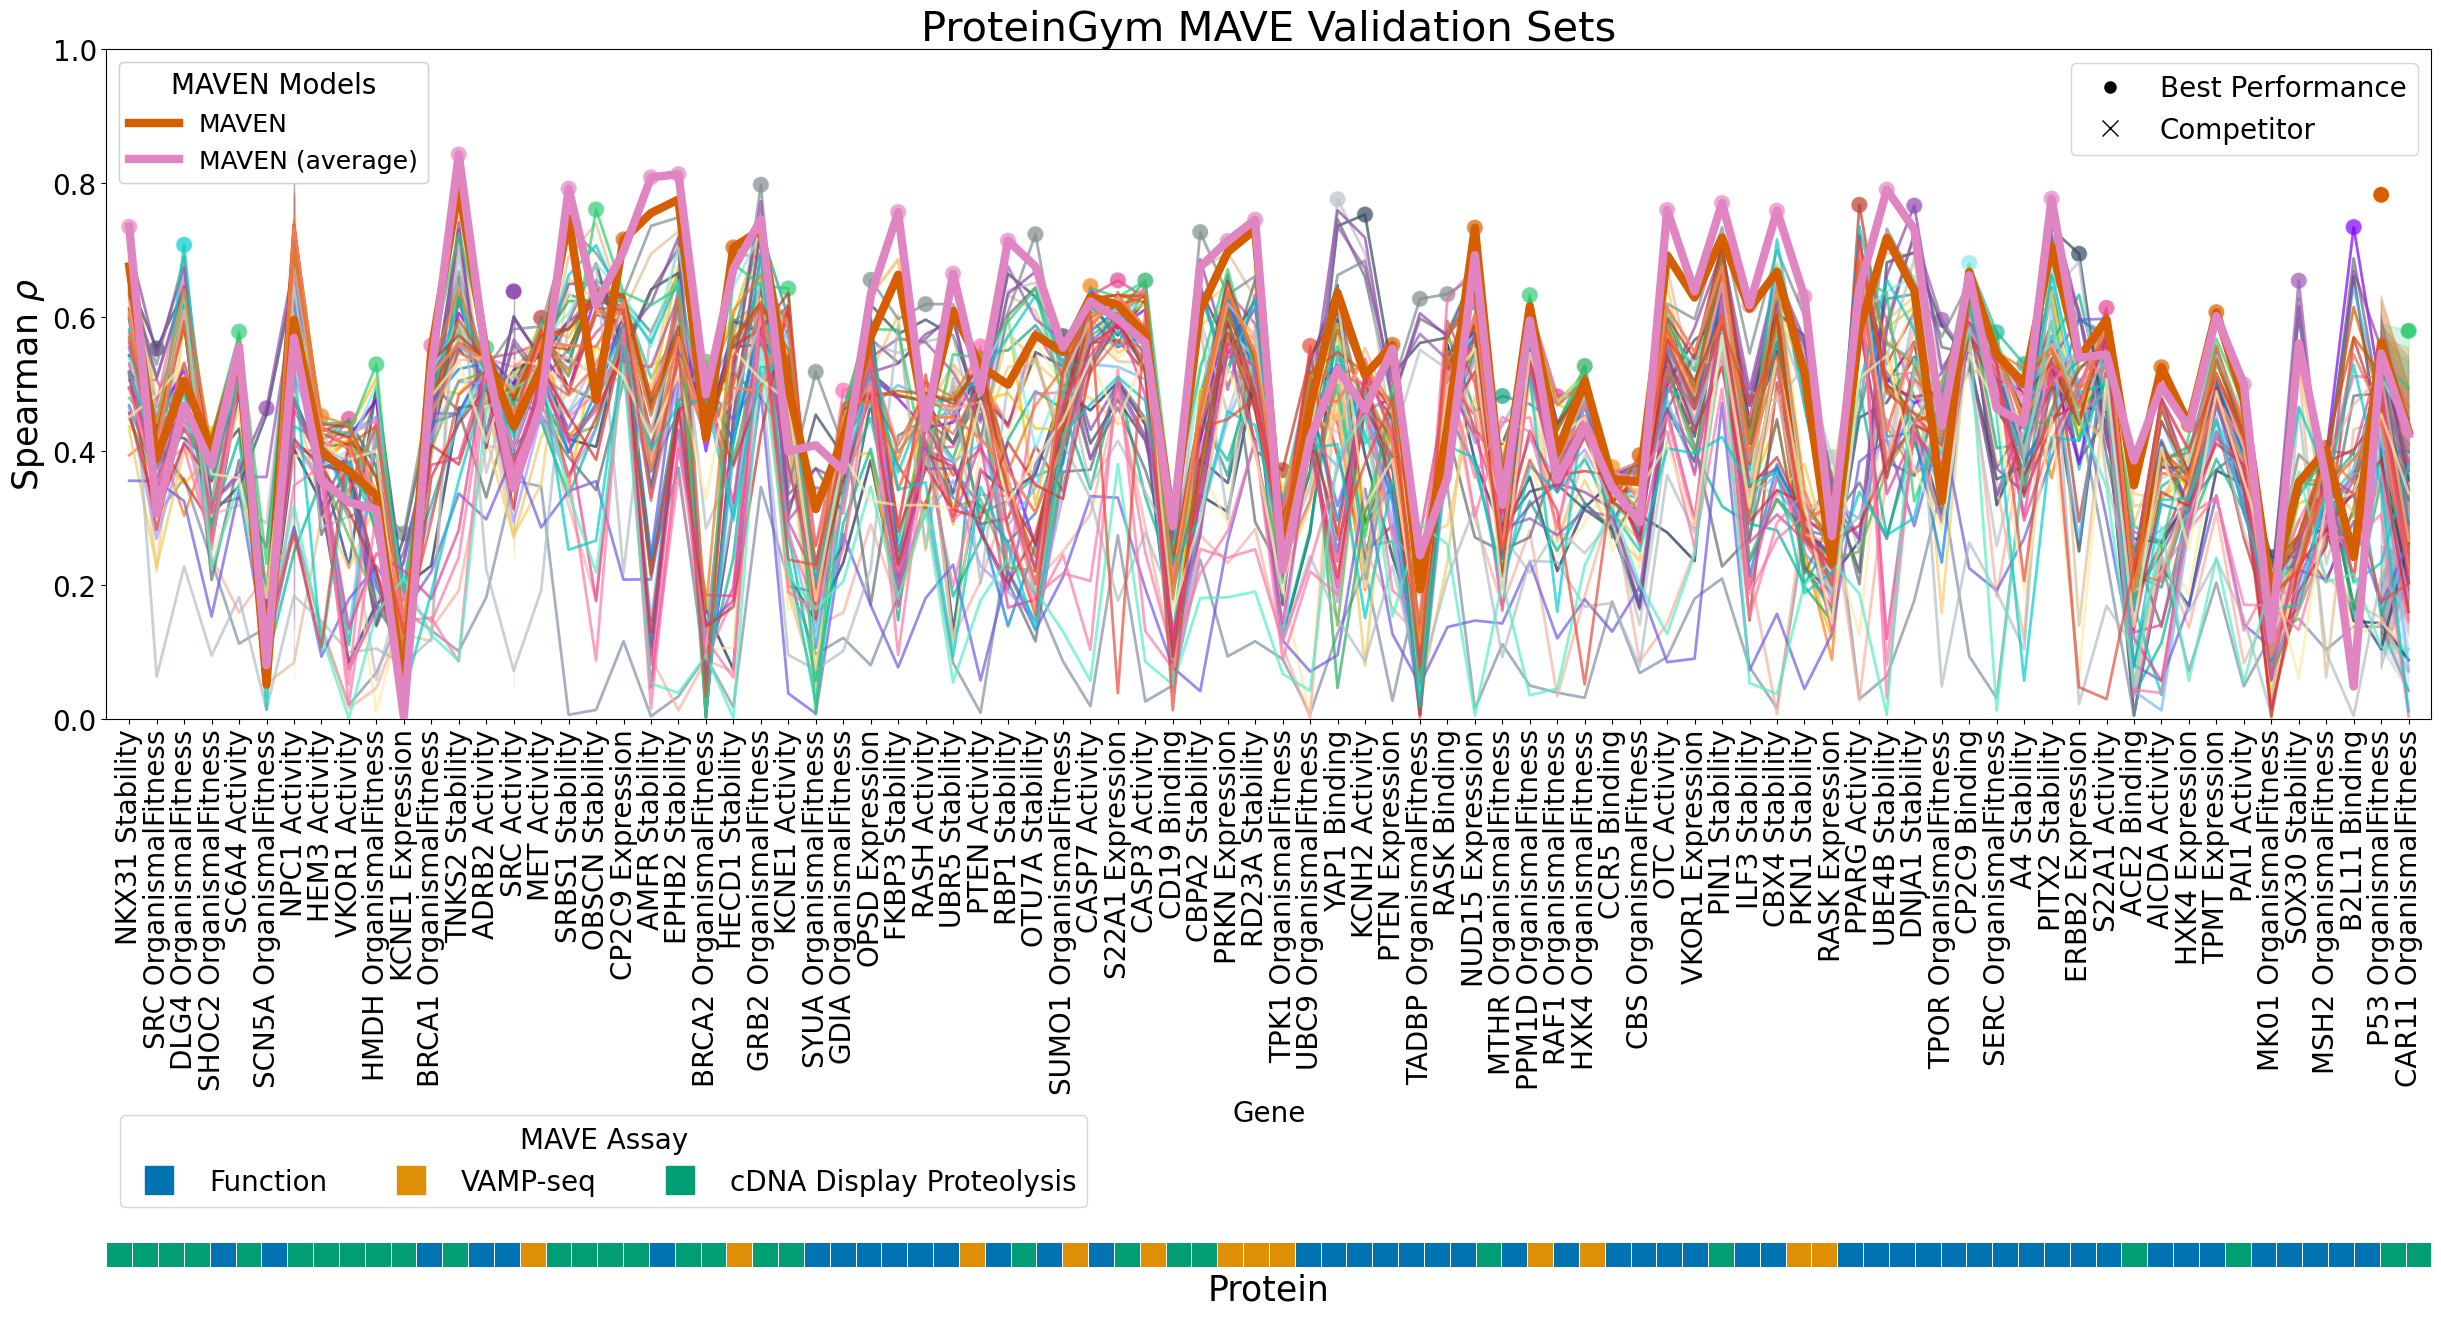

In [83]:
seq_of_genes = list(set(meta.columns))

# Ensure gene order is set as categorical in all relevant DataFrames
from pandas.api.types import CategoricalDtype

gene_order = CategoricalDtype(categories=seq_of_genes, ordered=True)

# Apply to all DataFrames that include the 'Gene' column
marker1['Gene'] = marker1['Gene'].astype(gene_order)
marker2['Gene'] = marker2['Gene'].astype(gene_order)
plot_df_raw_score['Gene'] = plot_df_raw_score['Gene'].astype(gene_order)

fig,ax = plt.subplots(2, figsize=(30,20))
sns.scatterplot(data=marker1, x='Gene', y='Spearman Correlation Coefficient', hue='Method',marker='o',palette=feature_colors,legend=False,s=150,alpha=0.7,ax=ax[0])
sns.scatterplot(data=marker2, x='Gene', y='Spearman Correlation Coefficient', hue='Method',marker="x",palette=feature_colors,s=50,ec='face',linewidth=1,legend=False,alpha=0.7,ax=ax[0])
sns.lineplot(data=plot_df_raw_score, x='Gene', y='Spearman Correlation Coefficient', hue='Method', lw=2, linestyle='-',palette=feature_colors,alpha=0.7,ax=ax[0])
patch1 = Line2D([], [], color="black", marker='o',linestyle='None',markersize=8)
patch2 = Line2D([], [], color="black", marker="x",linewidth=1,linestyle='None',markersize=12)
ax[0].tick_params('both',labelsize=20)
ax[0].tick_params('x',rotation=90)
legend1 = ax[0].legend(loc=3,fontsize=20,ncol=4)
for leg in legend1.get_lines():
    leg.set_linewidth(3.0)
#ax[0].add_artist(legend1)
legend2 = ax[0].legend((patch1,patch2), ('Best Performance', 'Competitor'), loc="upper right",fontsize=20)
ax[0].add_artist(legend2)
ax[0].set_ylabel('Spearman ' + r'$\rho$',fontsize=25)
ax[0].set_xlabel('',fontsize=20)
ax[0].set_title('ProteinGym MAVE Validation Sets',fontsize=30)
ax[0].set_ylim([0,1])

patch3 = Line2D([], [], color=sns.color_palette("colorblind").as_hex()[0], marker='s',linestyle='None',markersize=20)
patch4 = Line2D([], [], color=sns.color_palette("colorblind").as_hex()[1], marker='s',linestyle='None',markersize=20)
patch5 = Line2D([], [], color=sns.color_palette("colorblind").as_hex()[2], marker='s',linestyle='None',markersize=20)

legend3 = ax[0].legend((patch3, patch4, patch5), ('Function', 'VAMP-seq', 'cDNA Display Proteolysis'),
                       fontsize=20, ncols=3, title='MAVE Assay', title_fontsize=20,
                       loc='lower left', bbox_to_anchor=[0, -0.75])
ax[0].add_artist(legend3)  # ✅ Make sure this stays


sns.heatmap(meta, cmap=sns.color_palette("colorblind").as_hex()[0:3],cbar=False,yticklabels=False,xticklabels=False,square = True,linewidths=.5,ax=ax[1])
ax[1].set_xlabel('Protein',fontsize=25)
ax[0].margins(x=0.01)
plt.subplots_adjust(wspace=0, hspace=0.3)

### In order to bold the lines corresponding to MAVEN/MAVEN (average) ... 

from matplotlib.lines import Line2D

# Replot MAVEN and MAVEN (average) with thicker lines
highlight_methods = ["MAVEN", "MAVEN (average)"]
maven_handles = []

for method in highlight_methods:
    subset = plot_df_raw_score[plot_df_raw_score['Method'] == method]
    sns.lineplot(
        data=subset,
        x='Gene',
        y='Spearman Correlation Coefficient',
        hue='Method',
        lw=6,
        palette=feature_colors,
        legend=False,
        alpha=1.0,
        zorder=10,
        ax=ax[0]
    )
    maven_handles.append(
        Line2D([], [], label=method, color=feature_colors[method], lw=6)
    )

# Create legend ONLY for MAVEN models
maven_legend = ax[0].legend(
    handles=maven_handles,
    title="MAVEN Models",
    loc="upper left",
    fontsize=18,
    title_fontsize=20
)

# Explicitly add it as an artist so it doesn't override previous legends
ax[0].add_artist(maven_legend)



###
#plt.savefig('final_figures/ProteinGym_MAVE_validation_performance.svg')

plt.show()